In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def sho_expects(del_t,period_number, eta, k, gamma, x0, p0):
    

    #We will multiply all values by scale values at the end to get real values 
    #Real params 
    w1_real = 50000 * 2*np.pi  #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #Js
     
    x = x0
    p = p0
    exp_x, exp_p,exp_x_sq,exp_p_sq = [x], [p], [0],[0]
    
    
    #Define scale values such that w1, m are 1
    w1_scale = w1_real
    m_scale = m_bead
    
    #Define scale factors for position and momentum 
    x_scale = np.sqrt(hbar/(m_scale*w1_scale))
    p_scale = np.sqrt(hbar*m_scale*w1_scale)
    t_scale = 1/w1_scale
    

    w1 = w1_real/w1_scale
    m = m_bead/m_scale
    
    
    T = (2*np.pi)/w1
    t = period_number*T
    
    steps = int(t/del_t)
    t_arr = np.linspace(0, t, steps)
    t_per_arr = t_arr/T
    
    
    alpha_x_stream = [0]
    alpha_p_stream = []
    
    var_x = 1/(2*m*w1)
    var_p = m*w1/2
    cov_xp = 0
    
    
    for i in range(steps-1):
        del_W = np.random.normal(loc=0.0, scale=np.sqrt(del_t), size=None)
        
        del_Q = 4*eta*k*x*del_t + np.sqrt(2*eta*k)*del_W
        
        
        x += (1/m*p*del_t) -8*eta*k*x*var_x*del_t + 2*var_x*del_Q - gamma*p*del_t
        p += (-m* w1**2*x*del_t) -8*eta*k*x*cov_xp*del_t + 2*cov_xp*del_Q
        
        var_x += ((2/m*cov_xp) - (8*eta*k*var_x**2)) * del_t
        var_p += ((-2*m*w1**2*cov_xp) + 2*k - (8*eta*k*cov_xp**2)) * del_t
        cov_xp += (1/m*var_p - m*w1**2*var_x - (8*eta*k*var_x*cov_xp)) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2 
        
       
        exp_x.append(x)
        exp_p.append(p)
        
        exp_x_sq.append(x_sq)
        exp_p_sq.append(p_sq)
        
        
    t_real_arr = t_arr *t_scale
    exp_x_real  = np.array(exp_x) * x_scale
    exp_p_real  = np.array(exp_p) * p_scale
    exp_x_sq_real = np.array(exp_x_sq) * x_scale**2
    exp_p_sq_real = np.array(exp_p_sq) * p_scale**2

    var_x_real = var_x * x_scale**2
    var_p_real = var_p * p_scale**2
    cov_xp_real = cov_xp * x_scale * p_scale
    
    alpha_x_stream_real = np.array(alpha_x_stream) * x_scale
    alpha_p_stream_real = np.array(alpha_p_stream) * p_scale
    
    
    return [t_real_arr, t_per_arr,exp_x_real,exp_p_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real]
 

In [7]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = sho_expects(del_t=0.1,period_number=100, eta=1, k=0.05, gamma=0.01, x0=20, p0=20)

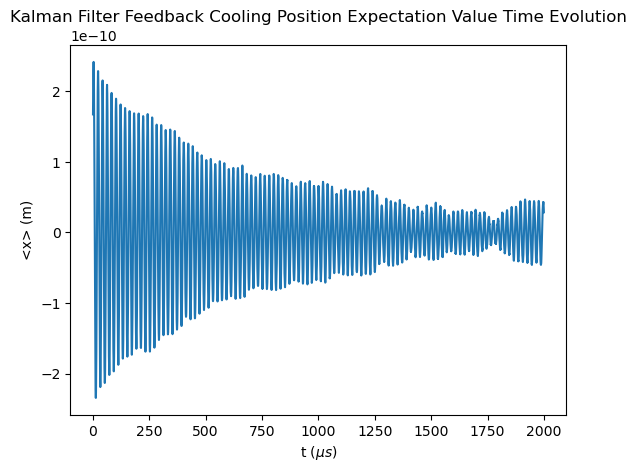

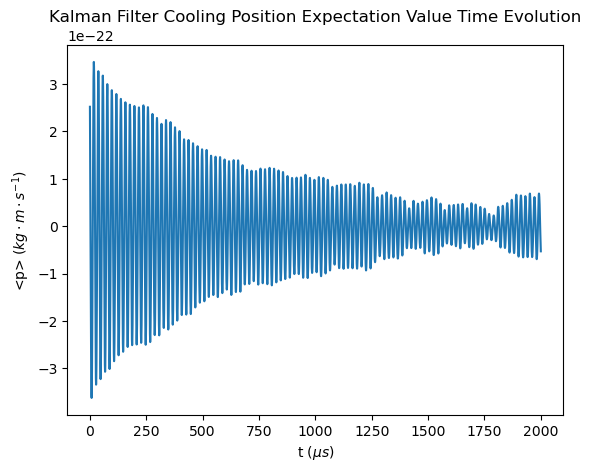

In [8]:
plt.figure()
plt.plot(t_real_arr*10**6, exp_x_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Kalman Filter Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Kalman Filter Cooling Position Expectation Value Time Evolution")
plt.show()



In [10]:
def t_eff(p_sq, x_sq, m, w):
    kB = 1.3806*10**-23
    
    T_eff = (p_sq/m + m*w**2*x_sq)/(2*kB)
    return T_eff
    

In [27]:
gamma_list = np.logspace(-3, 0.5, num=6)
gamma_list_real = gamma_list* 50000
w1_real = 50000 * 2*np.pi  #rad/s
m_bead = 4.8e-18 #kg
T_list = []

In [28]:
for gamma in gamma_list:
    t_real_arr, t_per_arr,exp_x_real,exp_p_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = sho_expects(del_t=0.1,period_number=5500, eta=1, k=0.05, gamma=gamma, x0=20, p0=20)
    x_sq_real = np.mean(exp_x_sq_real[-2500:])
    p_sq_real = np.mean(exp_p_sq_real[-2500:])

    t_e = t_eff(p_sq_real, x_sq_real, m=m_bead, w=w1_real)
    T_list.append(t_e)
    

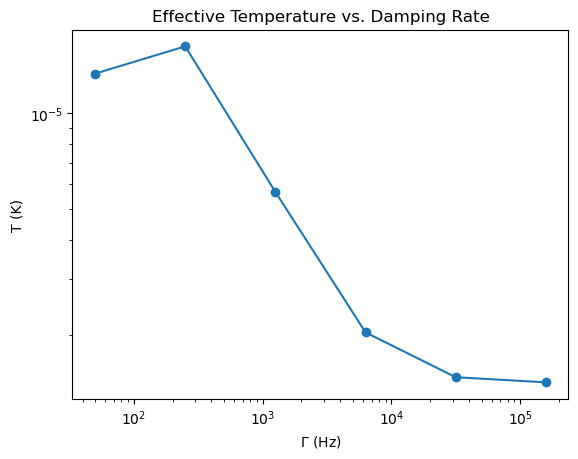

In [31]:
plt.figure()
plt.scatter(gamma_list_real, np.array(T_list))
plt.plot(gamma_list_real, np.array(T_list))
plt.xlabel(r"$\Gamma$ (Hz)")
plt.ylabel("T (K)")
plt.title("Effective Temperature vs. Damping Rate")
plt.loglog()
plt.show()

In [15]:
T_list_meas = np.array([np.float64(0.0003001267352518879),
 np.float64(3.525417195155775e-05),
 np.float64(4.624267833353859e-06),
 np.float64(1.6643329312516906e-06),
 np.float64(2.575825800233709e-06),
 np.float64(4.300584297653723e-05)])

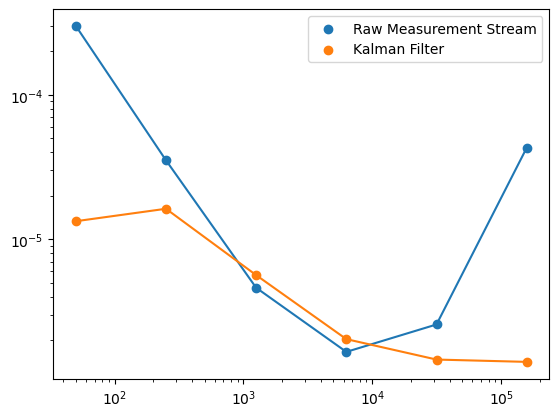

In [32]:
#Overplot Measurement Stream vs. Kalman Filter

plt.figure()
plt.scatter(gamma_list_real, T_list_meas, label= "Raw Measurement Stream")
plt.plot(gamma_list_real, T_list_meas)
plt.scatter(gamma_list_real, T_list, label= "Kalman Filter")
plt.plot(gamma_list_real, T_list)
plt.loglog()
plt.legend()
plt.show()